In [11]:
# Walmart Sales Analytics Study
# Gurunandhan "Guru" Pillai
# For Google Colab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [12]:
# Load Walmart weekly sales dataset

df = pd.read_csv("/Walmart_Sales.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [13]:
# Basic data inspection

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows: 6435
Columns: 8

Column names:
['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

Data types:
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Missing values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate rows:
0


In [14]:
# Clean and prepare the dataset

# Convert Date from text to datetime format
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# Remove duplicate rows if any are present
df = df.drop_duplicates().copy()

# Create useful time-based fields for analysis
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Year_Month"] = df["Date"].dt.to_period("M")

print("Cleaned dataset shape:", df.shape)

print("\nUpdated data types:")
print(df.dtypes)

display(df.head())

Cleaned dataset shape: (6435, 12)

Updated data types:
Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
Year                     int32
Month                    int32
Month_Name              object
Year_Month           period[M]
dtype: object


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_Name,Year_Month
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,Feb,2010-02
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,Feb,2010-02
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,Feb,2010-02
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,Feb,2010-02
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,Mar,2010-03


In [15]:
# Validate data quality after preparation

print("Missing values after preparation:")
print(df.isna().sum())

print("\nDuplicate rows after preparation:")
print(df.duplicated().sum())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nNumber of unique stores:")
print(df["Store"].nunique())

print("\nWeekly sales summary:")
print(df["Weekly_Sales"].describe())

Missing values after preparation:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Month_Name      0
Year_Month      0
dtype: int64

Duplicate rows after preparation:
0

Date range:
2010-02-05 00:00:00 to 2012-10-26 00:00:00

Number of unique stores:
45

Weekly sales summary:
count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64


In [16]:
# Calculate overall sales KPIs

total_sales = df["Weekly_Sales"].sum()
average_weekly_sales = df["Weekly_Sales"].mean()
median_weekly_sales = df["Weekly_Sales"].median()
number_of_stores = df["Store"].nunique()
number_of_records = len(df)

print("=== WALMART SALES KPIs ===")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Weekly Sales: ${average_weekly_sales:,.2f}")
print(f"Median Weekly Sales: ${median_weekly_sales:,.2f}")
print(f"Number of Stores: {number_of_stores}")
print(f"Number of Records: {number_of_records:,}")

=== WALMART SALES KPIs ===
Total Sales: $6,737,218,987.11
Average Weekly Sales: $1,046,964.88
Median Weekly Sales: $960,746.04
Number of Stores: 45
Number of Records: 6,435


In [17]:
# Analyze store-level sales performance

store_sales = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
)

# Display the top 10 stores
print("=== TOP 10 STORES BY TOTAL SALES ===")
print(store_sales.head(10))

# Calculate contribution of the top 5 stores
top_5_sales = store_sales.head(5).sum()
top_5_percentage = (top_5_sales / total_sales) * 100

# Identify highest-performing store
top_store = store_sales.index[0]
top_store_sales = store_sales.iloc[0]
top_store_percentage = (top_store_sales / total_sales) * 100

print("\n=== KEY STORE INSIGHTS ===")
print(f"Top 5 Stores Combined Sales: ${top_5_sales:,.2f}")
print(f"Top 5 Stores Share of Total Sales: {top_5_percentage:.2f}%")
print(f"Highest-Selling Store: Store {top_store}")
print(f"Store {top_store} Total Sales: ${top_store_sales:,.2f}")
print(f"Store {top_store} Share of Total Sales: {top_store_percentage:.2f}%")

=== TOP 10 STORES BY TOTAL SALES ===
Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

=== KEY STORE INSIGHTS ===
Top 5 Stores Combined Sales: $1,451,841,801.96
Top 5 Stores Share of Total Sales: 21.55%
Highest-Selling Store: Store 20
Store 20 Total Sales: $301,397,792.46
Store 20 Share of Total Sales: 4.47%


In [18]:
# Compare holiday and non-holiday sales performance

holiday_sales = (
    df.groupby("Holiday_Flag")["Weekly_Sales"]
      .agg(["count", "mean", "sum"])
)

holiday_sales.index = ["Non-Holiday", "Holiday"]

print("=== HOLIDAY VS NON-HOLIDAY SALES ===")
display(holiday_sales)

# Calculate percentage difference in average weekly sales
non_holiday_avg = holiday_sales.loc["Non-Holiday", "mean"]
holiday_avg = holiday_sales.loc["Holiday", "mean"]

holiday_difference = (
    (holiday_avg - non_holiday_avg) / non_holiday_avg
) * 100

print("\n=== KEY HOLIDAY INSIGHT ===")
print(f"Average Non-Holiday Weekly Sales: ${non_holiday_avg:,.2f}")
print(f"Average Holiday Weekly Sales: ${holiday_avg:,.2f}")
print(f"Holiday vs Non-Holiday Difference: {holiday_difference:.2f}%")

=== HOLIDAY VS NON-HOLIDAY SALES ===


,count,mean,sum
Non-Holiday,5985,1.041256e+06,6.231919e+09
Holiday,450,1.122888e+06,5.052996e+08



=== KEY HOLIDAY INSIGHT ===
Average Non-Holiday Weekly Sales: $1,041,256.38
Average Holiday Weekly Sales: $1,122,887.89
Holiday vs Non-Holiday Difference: 7.84%


In [19]:
# Analyze monthly sales trends

monthly_sales = (
    df.groupby("Year_Month")["Weekly_Sales"]
      .sum()
      .sort_index()
)

print("=== MONTHLY SALES TREND ===")
display(monthly_sales)

# Identify highest and lowest sales months
highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("\n=== KEY MONTHLY INSIGHTS ===")
print(f"Highest-Sales Month: {highest_month}")
print(f"Highest Monthly Sales: ${highest_month_sales:,.2f}")
print(f"Lowest-Sales Month: {lowest_month}")
print(f"Lowest Monthly Sales: ${lowest_month_sales:,.2f}")

=== MONTHLY SALES TREND ===


,Weekly_Sales
Year_Month,
2010-02,1.903330e+08
2010-03,1.819198e+08
2010-04,2.314124e+08
2010-05,1.867109e+08
2010-06,1.922462e+08
2010-07,2.325801e+08
2010-08,1.876401e+08
2010-09,1.772679e+08
2010-10,2.171618e+08



=== KEY MONTHLY INSIGHTS ===
Highest-Sales Month: 2010-12
Highest Monthly Sales: $288,760,532.72
Lowest-Sales Month: 2011-01
Lowest Monthly Sales: $163,703,966.83


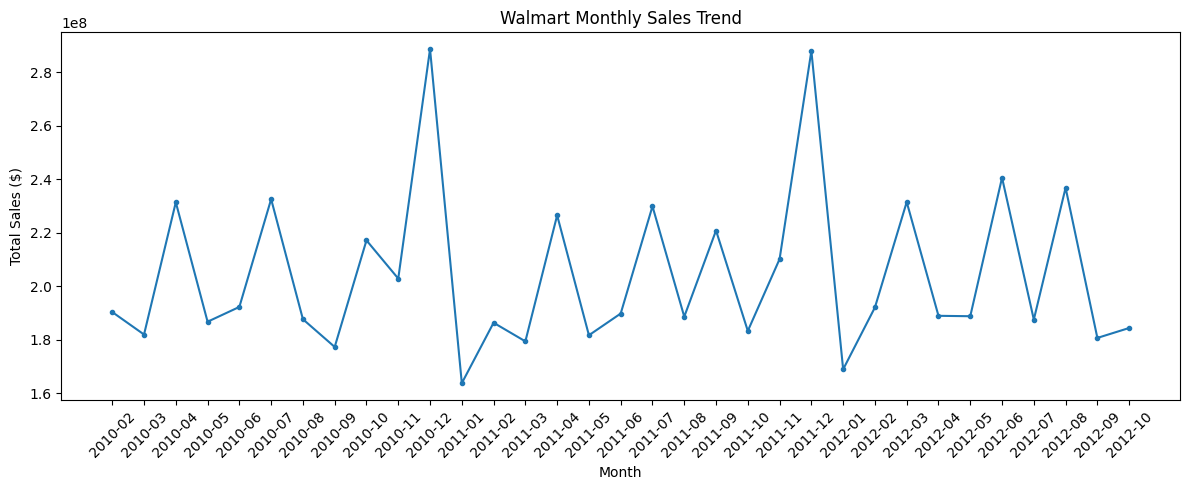

In [20]:
# Visualize monthly sales trend

monthly_sales_chart = monthly_sales.copy()
monthly_sales_chart.index = monthly_sales_chart.index.astype(str)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales_chart.index,
    monthly_sales_chart.values,
    marker="o",
    markersize=3
)

plt.title("Walmart Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")

plt.xticks(rotation=45)

plt.tight_layout()

# Save chart for GitHub portfolio
plt.savefig(
    "walmart_monthly_sales_trend.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

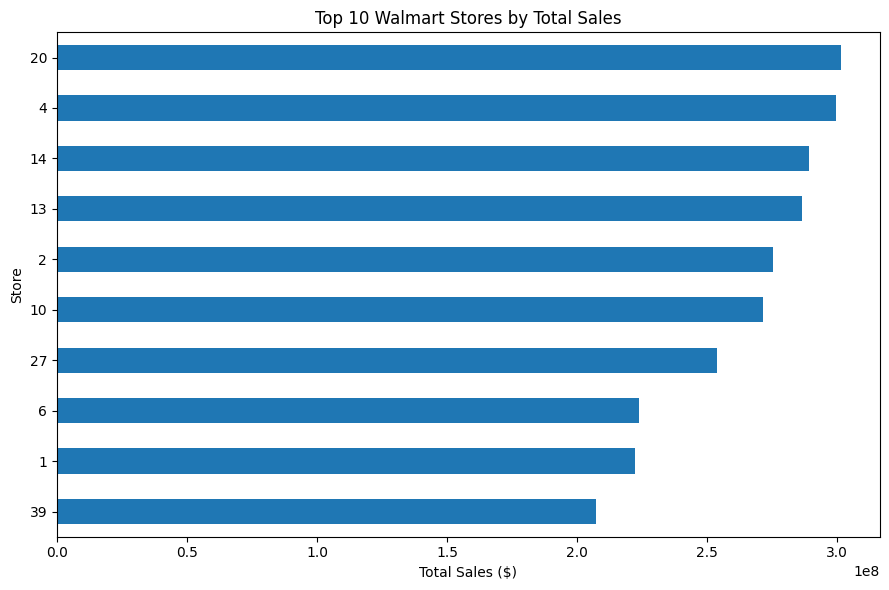

In [21]:
# Visualize top 10 stores by total sales

top_10_stores = store_sales.head(10).sort_values()

plt.figure(figsize=(9, 6))

top_10_stores.plot(kind="barh")

plt.title("Top 10 Walmart Stores by Total Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Store")

plt.tight_layout()

# Save chart for GitHub portfolio
plt.savefig(
    "walmart_top_10_stores.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

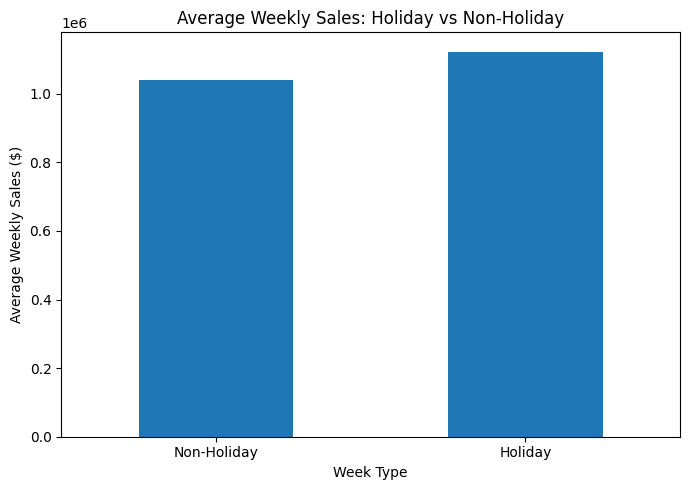

In [22]:
# Visualize average sales during holiday vs non-holiday weeks

holiday_chart = pd.Series({
    "Non-Holiday": non_holiday_avg,
    "Holiday": holiday_avg
})

plt.figure(figsize=(7, 5))

holiday_chart.plot(kind="bar")

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales ($)")
plt.xticks(rotation=0)

plt.tight_layout()

# Save chart for GitHub portfolio
plt.savefig(
    "walmart_holiday_vs_nonholiday.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [23]:
# Analyze correlations between economic factors and weekly sales

economic_columns = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

correlation_matrix = df[economic_columns].corr()

print("=== CORRELATION WITH WEEKLY SALES ===")

sales_correlations = (
    correlation_matrix["Weekly_Sales"]
    .drop("Weekly_Sales")
    .sort_values(ascending=False)
)

print(sales_correlations)

=== CORRELATION WITH WEEKLY SALES ===
Fuel_Price      0.009464
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Name: Weekly_Sales, dtype: float64


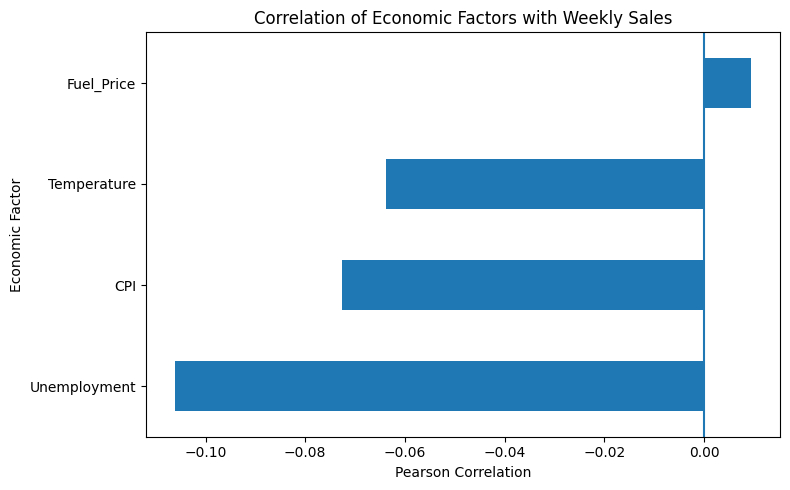

In [24]:
# Visualize correlations with weekly sales

sales_correlations_sorted = sales_correlations.sort_values()

plt.figure(figsize=(8, 5))

sales_correlations_sorted.plot(kind="barh")

plt.title("Correlation of Economic Factors with Weekly Sales")
plt.xlabel("Pearson Correlation")
plt.ylabel("Economic Factor")

plt.axvline(0)

plt.tight_layout()

plt.savefig(
    "walmart_sales_correlations.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Export the prepared dataset for SQL and Tableau analysis

df.to_csv(
    "walmart_sales_cleaned.csv",
    index=False
)

print("walmart_sales_cleaned.csv exported successfully.")
print("Exported rows:", len(df))
print("Exported columns:", len(df.columns))

walmart_sales_cleaned.csv exported successfully.
Exported rows: 6435
Exported columns: 12


In [26]:
# Generate final project findings from the analyzed data

print("=== WALMART SALES ANALYTICS — KEY FINDINGS ===")

print(
    f"\n1. Total sales across the dataset were "
    f"${total_sales:,.2f}."
)

print(
    f"\n2. The top five stores generated "
    f"${top_5_sales:,.2f}, representing "
    f"{top_5_percentage:.2f}% of total sales."
)

print(
    f"\n3. Store {top_store} was the highest-selling store, "
    f"generating ${top_store_sales:,.2f}."
)

print(
    f"\n4. Average store-week sales during holiday periods were "
    f"${holiday_avg:,.2f}, compared with "
    f"${non_holiday_avg:,.2f} during non-holiday periods."
)

print(
    f"This represents a {holiday_difference:.2f}% higher "
    f"average during holiday periods."
)

print(
    f"\n5. {highest_month} recorded the highest aggregate "
    f"monthly sales at ${highest_month_sales:,.2f}."
)

print(
    "\n6. Fuel price, temperature, CPI, and unemployment "
    "showed only weak linear correlations with weekly sales."
)

=== WALMART SALES ANALYTICS — KEY FINDINGS ===

1. Total sales across the dataset were $6,737,218,987.11.

2. The top five stores generated $1,451,841,801.96, representing 21.55% of total sales.

3. Store 20 was the highest-selling store, generating $301,397,792.46.

4. Average store-week sales during holiday periods were $1,122,887.89, compared with $1,041,256.38 during non-holiday periods.
This represents a 7.84% higher average during holiday periods.

5. 2010-12 recorded the highest aggregate monthly sales at $288,760,532.72.

6. Fuel price, temperature, CPI, and unemployment showed only weak linear correlations with weekly sales.
